# Подключение необходимых библиотек

In [51]:
import os
import numpy as np
import math
import time
import matplotlib.pyplot as plt

import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
from pycuda import curandom
CUDA_AVAILABLE = True

# CUDA ядро

In [52]:
cuda_kernel = """
__global__ void pi_monte_carlo(float *points, int *count, int N)
{
    extern __shared__ int shared[];

    int tid = threadIdx.x;
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    shared[tid] = 0;

    if (idx < N) {
        float x = points[2 * idx];
        float y = points[2 * idx + 1];

        if (x * x + y * y <= 1.0f) {
            shared[tid] = 1;
        }
    }

    __syncthreads();

    for (int k = blockDim.x / 2; k > 0; k /= 2) {
        if (tid < k) {
            shared[tid] += shared[tid + k];
        }
        __syncthreads();
    }

    if (tid == 0) {
        atomicAdd(count, shared[0]);
    }
}
"""

module = SourceModule(cuda_kernel)
pi_monte_carlo_gpu = module.get_function("pi_monte_carlo")

# Основная работа

In [53]:
def compute_pi_cpu(N: int) -> tuple:
    start = time.perf_counter()

    points = np.random.rand(N, 2).astype(np.float32)
    inside = np.sum(points[:, 0]**2 + points[:, 1]**2 <= 1.0)

    pi = 4.0 * inside / N
    elapsed_ms = (time.perf_counter() - start) * 1000

    return pi, elapsed_ms

def compute_pi_gpu(N):
    start = time.time()

    random_generator = curandom.XORWOWRandomNumberGenerator()
    points_gpu = random_generator.gen_uniform((N, 2), dtype=np.float32)

    count_gpu = cuda.mem_alloc(4)
    cuda.memcpy_htod(count_gpu, np.array([0], dtype=np.int32))

    block_size = 256
    grid_size = (N + block_size - 1) // block_size

    pi_monte_carlo_gpu(
        points_gpu, count_gpu, np.int32(N),
        block=(block_size, 1, 1),
        grid=(grid_size, 1),
        shared=block_size * 4
    )

    cuda.Context.synchronize()

    count = np.zeros(1, dtype=np.int32)
    cuda.memcpy_dtoh(count, count_gpu)

    pi = 4 * count[0] / N
    elapsed_ms = (time.time() - start) * 1000

    return pi, elapsed_ms

In [54]:
def run_benchmark():
    N_values = [
        5_000_000,
        10_000_000,
        20_000_000,
        50_000_000,
        100_000_000,
    ]

    results = []

    print(f"{'N':>12} | {'pi CPU':>12} | {'pi GPU':>12} | {'CPU (мс)':>10} | {'GPU (мс)':>10} | {'Ускорение':>10}")

    for N in N_values:
        pi_cpu, t_cpu = compute_pi_cpu(N)
        pi_gpu, t_gpu = compute_pi_gpu(N)
        speedup = t_cpu / t_gpu if t_gpu > 0 else 0

        results.append({
            'N': N,
            'pi_cpu': pi_cpu,
            'pi_gpu': pi_gpu,
            't_cpu_ms': t_cpu,
            't_gpu_ms': t_gpu,
            'speedup': speedup
        })

        print(f"{N:>12,} | {pi_cpu:>12.8f} | {pi_gpu:>12.8f} | {t_cpu:>10.2f} | {t_gpu:>10.2f} | {speedup:>10.2f}×")

        cuda.mem_get_info()

    return results

# Визуализация

In [55]:
def visualize_results(results):
    os.makedirs("results", exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    N_values = [r['N'] for r in results]
    cpu_times = [r['t_cpu_ms'] for r in results]
    gpu_times = [r['t_gpu_ms'] for r in results]
    speedups = [r['speedup'] for r in results]

    ax1 = axes[0]
    ax1.plot(N_values, cpu_times, 'o-', label='CPU', color='#e74c3c', linewidth=2, markersize=8)
    ax1.plot(N_values, gpu_times, 's-', label='GPU', color='#3498db', linewidth=2, markersize=8)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Количество точек', fontsize=12)
    ax1.set_ylabel('Время (мс)', fontsize=12)
    ax1.set_title('Время выполнения', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)

    for x, y_cpu, y_gpu in zip(N_values, cpu_times, gpu_times):
        ax1.annotate(f'{y_cpu:.0f}ms', (x, y_cpu), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
        ax1.annotate(f'{y_gpu:.0f}ms', (x, y_gpu), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

    ax2 = axes[1]
    colors = ['#27ae60' if s >= 1 else '#e74c3c' for s in speedups]
    bars = ax2.bar(range(len(N_values)), speedups, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(y=1, color='black', linestyle='--', linewidth=2, label='Ускорение = 1')
    ax2.set_xticks(range(len(N_values)))
    ax2.set_xticklabels([f'{n//1000000}M' for n in N_values], rotation=45)
    ax2.set_xlabel('Количество точек', fontsize=12)
    ax2.set_ylabel('Ускорение', fontsize=12)
    ax2.set_title('Ускорение GPU относительно CPU', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.legend(fontsize=11)

    for bar, speedup in zip(bars, speedups):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{speedup:.2f}x', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('results/benchmark_results.png', dpi=150, bbox_inches='tight')
    plt.show()

# Запуск

           N |       pi CPU |       pi GPU |   CPU (мс) |   GPU (мс) |  Ускорение
   5,000,000 |   3.14319360 |   3.14233760 |     121.29 |     195.29 |       0.62×
  10,000,000 |   3.14142160 |   3.14124560 |     259.48 |     196.44 |       1.32×
  20,000,000 |   3.14112500 |   3.14232460 |     494.93 |     209.88 |       2.36×
  50,000,000 |   3.14210376 |   3.14188168 |    1284.22 |     296.74 |       4.33×
 100,000,000 |   3.14166564 |   3.14161384 |    3263.26 |     274.44 |      11.89×


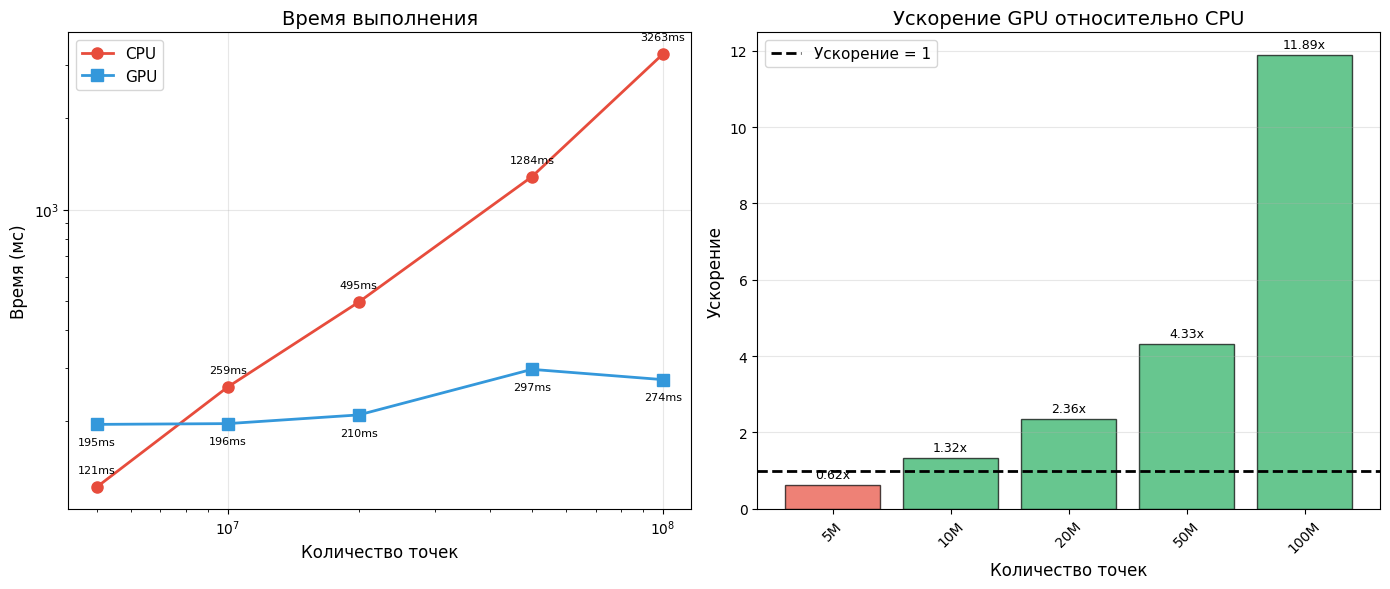

In [56]:
results = run_benchmark()
visualize_results(results)